<a href="https://colab.research.google.com/github/i2mmmmm/train_project/blob/main/20230818_vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets

In [3]:
from google.colab import drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data_s30 = pd.read_csv('/content/drive/My Drive/철도/data_s30.csv')
data_s40 = pd.read_csv('/content/drive/My Drive/철도/data_s40.csv')
data_s50 = pd.read_csv('/content/drive/My Drive/철도/data_s50.csv')
data_s70 = pd.read_csv('/content/drive/My Drive/철도/data_s70.csv')
data_s100 = pd.read_csv('/content/drive/My Drive/철도/data_s100.csv')
lane_data_s = pd.read_csv('/content/drive/My Drive/철도/lane_data_s.csv')

In [5]:
data_c30 = pd.read_csv('/content/drive/My Drive/철도/data_c30.csv')
data_c40 = pd.read_csv('/content/drive/My Drive/철도/data_c40.csv')
data_c50 = pd.read_csv('/content/drive/My Drive/철도/data_c50.csv')
data_c70 = pd.read_csv('/content/drive/My Drive/철도/data_c70.csv')
data_c100 = pd.read_csv('/content/drive/My Drive/철도/data_c100.csv')
lane_data_c = pd.read_csv('/content/drive/My Drive/철도/lane_data_c.csv')

In [6]:
new_column_name = {'Distance': 'Dis'}
lane_data_s = lane_data_s.rename(columns=new_column_name)
new_column_name = {'Distance': 'Dis'}
lane_data_c = lane_data_c.rename(columns=new_column_name)

In [7]:
s30_trail = pd.concat([lane_data_s, data_s30],axis=1)
s30_trail = s30_trail.drop('Dis', axis=1)
s40_trail = pd.concat([lane_data_s, data_s40],axis=1)
s40_trail = s40_trail.drop('Dis', axis=1)
s50_trail = pd.concat([lane_data_s, data_s50],axis=1)
s50_trail = s50_trail.drop('Dis', axis=1)
s70_trail = pd.concat([lane_data_s, data_s70],axis=1)
s70_trail = s70_trail.drop('Dis', axis=1)
s100_trail = pd.concat([lane_data_s, data_s100],axis=1)
s100_trail = s100_trail.drop('Dis', axis=1)
c30_trail = pd.concat([lane_data_c, data_c30],axis=1)
c30_trail = c30_trail.drop('Dis', axis=1)
c40_trail = pd.concat([lane_data_c, data_c40],axis=1)
c40_trail = c40_trail.drop('Dis', axis=1)
c50_trail = pd.concat([lane_data_c, data_c50],axis=1)
c50_trail = c50_trail.drop('Dis', axis=1)
c70_trail = pd.concat([lane_data_c, data_c70],axis=1)
c70_trail = c70_trail.drop('Dis', axis=1)
c100_trail = pd.concat([lane_data_c, data_c100],axis=1)
c100_trail = c100_trail.drop('Dis', axis=1)

In [ ]:
s30_trail = s30_trail[:10001]
s40_trail = s40_trail[:10001]
s50_trail = s50_trail[:10001]
s70_trail = s70_trail[:10001]
s100_trail = s100_trail[:10001]

c30_trail = c30_trail[:10001]
c40_trail = c40_trail[:10001]
c50_trail = c50_trail[:10001]
c70_trail = c70_trail[:10001]
c100_trail = c100_trail[:10001]

In [16]:
s30_trail.columns

Index(['Cross level', 'Curvature', 'Lateral', 'Vertical', 'Gauge', 'Distance',
       'A_M1_C_B1_Y', 'A_M1_C_B1_Z', 'A_M1_B1_W1_Y_L', 'A_M1_B1_BC_Y_L',
       'A_M1_B1_W2_Y_L', 'A_M1_B1_W1_Y_R', 'A_M1_B1_BC_Y_R', 'A_M1_B1_W2_Y_R',
       'A_M1_B1_W1_Z_L', 'A_M1_B1_BC_Z_L', 'A_M1_B1_W2_Z_L', 'A_M1_B1_W1_Z_R',
       'A_M1_B1_BC_Z_R', 'A_M1_B1_W2_Z_R', 'A__B1_W1_Y_A_axle_L',
       'A__B1_W2_Y_A_axle_L', 'A__B1_W1_Y_A_axle_R', 'A__B1_W2_Y_A_axle_R',
       'A__B1_W1_Z_A_axle_L', 'A__B1_W2_Z_A_axle_L', 'A__B1_W1_Z_A_axle_R',
       'A__B1_W2_Z_A_axle_R', 'V_M1_B1_W1_L', 'V_M1_B1_W1_R', 'QL_M1_B1_W1',
       'QR_M1_B1_W1', 'V_M1_B1_W2_L', 'V_M1_B1_W2_R', 'QL_M1_B1_W2',
       'QR_M1_B1_W2', 'YL_M1_B1_W1', 'YR_M1_B1_W1', 'YL_M1_B1_W2',
       'YR_M1_B1_W2'],
      dtype='object')

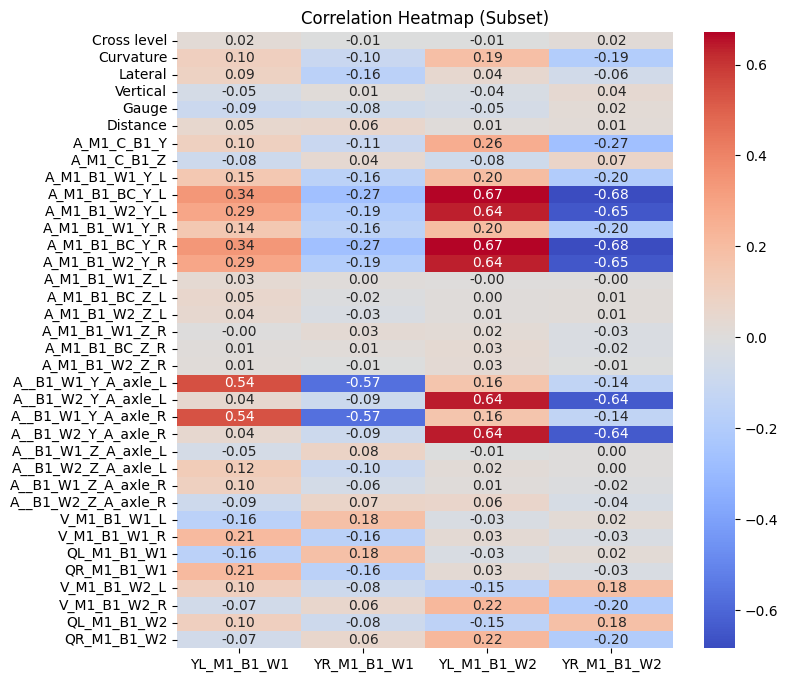

In [48]:
# 독립 변수(a부터 h)와 타겟 변수(i, j) 선택
independent_cols = ['Cross level', 'Curvature', 'Lateral', 'Vertical', 'Gauge', 'Distance',
       'A_M1_C_B1_Y', 'A_M1_C_B1_Z', 'A_M1_B1_W1_Y_L', 'A_M1_B1_BC_Y_L',
       'A_M1_B1_W2_Y_L', 'A_M1_B1_W1_Y_R', 'A_M1_B1_BC_Y_R', 'A_M1_B1_W2_Y_R',
       'A_M1_B1_W1_Z_L', 'A_M1_B1_BC_Z_L', 'A_M1_B1_W2_Z_L', 'A_M1_B1_W1_Z_R',
       'A_M1_B1_BC_Z_R', 'A_M1_B1_W2_Z_R', 'A__B1_W1_Y_A_axle_L',
       'A__B1_W2_Y_A_axle_L', 'A__B1_W1_Y_A_axle_R', 'A__B1_W2_Y_A_axle_R',
       'A__B1_W1_Z_A_axle_L', 'A__B1_W2_Z_A_axle_L', 'A__B1_W1_Z_A_axle_R',
       'A__B1_W2_Z_A_axle_R', 'V_M1_B1_W1_L', 'V_M1_B1_W1_R', 'QL_M1_B1_W1',
       'QR_M1_B1_W1', 'V_M1_B1_W2_L', 'V_M1_B1_W2_R', 'QL_M1_B1_W2',
       'QR_M1_B1_W2']
target_cols = ['YL_M1_B1_W1', 'YR_M1_B1_W1', 'YL_M1_B1_W2', 'YR_M1_B1_W2']

# 선택한 열로 데이터프레임 생성
selected_data = s30_trail[independent_cols + target_cols]

# 상관관계 행렬 계산
correlation_matrix = selected_data.corr()

# 상관관계 행렬 출력
#print(correlation_matrix.loc[independent_cols, target_cols])

# 상관관계 시각화
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix.loc[independent_cols, target_cols], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Subset)")
plt.show()



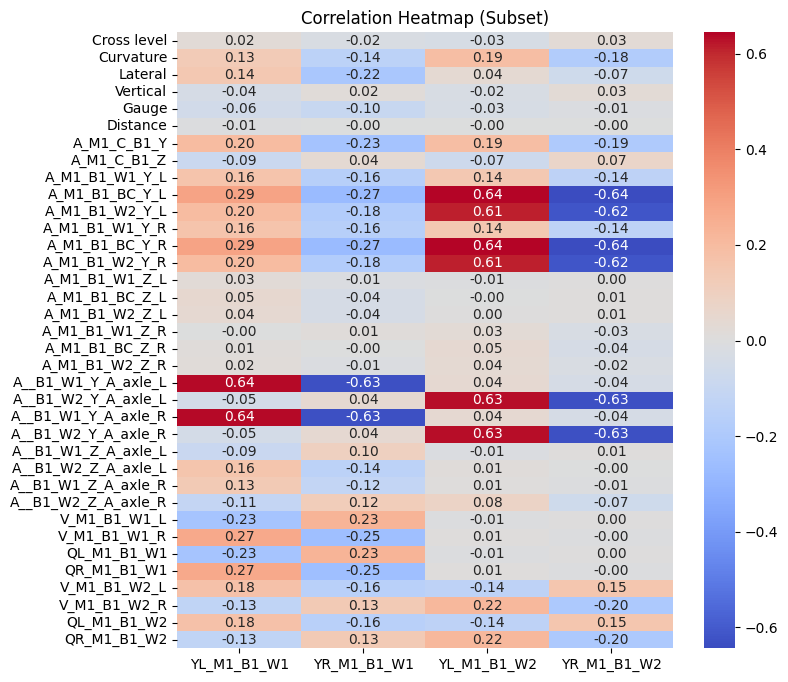

In [47]:
# 독립 변수(a부터 h)와 타겟 변수(i, j) 선택
independent_cols = ['Cross level', 'Curvature', 'Lateral', 'Vertical', 'Gauge', 'Distance',
       'A_M1_C_B1_Y', 'A_M1_C_B1_Z', 'A_M1_B1_W1_Y_L', 'A_M1_B1_BC_Y_L',
       'A_M1_B1_W2_Y_L', 'A_M1_B1_W1_Y_R', 'A_M1_B1_BC_Y_R', 'A_M1_B1_W2_Y_R',
       'A_M1_B1_W1_Z_L', 'A_M1_B1_BC_Z_L', 'A_M1_B1_W2_Z_L', 'A_M1_B1_W1_Z_R',
       'A_M1_B1_BC_Z_R', 'A_M1_B1_W2_Z_R', 'A__B1_W1_Y_A_axle_L',
       'A__B1_W2_Y_A_axle_L', 'A__B1_W1_Y_A_axle_R', 'A__B1_W2_Y_A_axle_R',
       'A__B1_W1_Z_A_axle_L', 'A__B1_W2_Z_A_axle_L', 'A__B1_W1_Z_A_axle_R',
       'A__B1_W2_Z_A_axle_R', 'V_M1_B1_W1_L', 'V_M1_B1_W1_R', 'QL_M1_B1_W1',
       'QR_M1_B1_W1', 'V_M1_B1_W2_L', 'V_M1_B1_W2_R', 'QL_M1_B1_W2',
       'QR_M1_B1_W2']
target_cols = ['YL_M1_B1_W1', 'YR_M1_B1_W1', 'YL_M1_B1_W2', 'YR_M1_B1_W2']

# 선택한 열로 데이터프레임 생성
selected_data = s40_trail[independent_cols + target_cols]

# 상관관계 행렬 계산
correlation_matrix = selected_data.corr()

# 상관관계 행렬 출력
#print(correlation_matrix.loc[independent_cols, target_cols])

# 상관관계 시각화
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix.loc[independent_cols, target_cols], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Subset)")
plt.show()

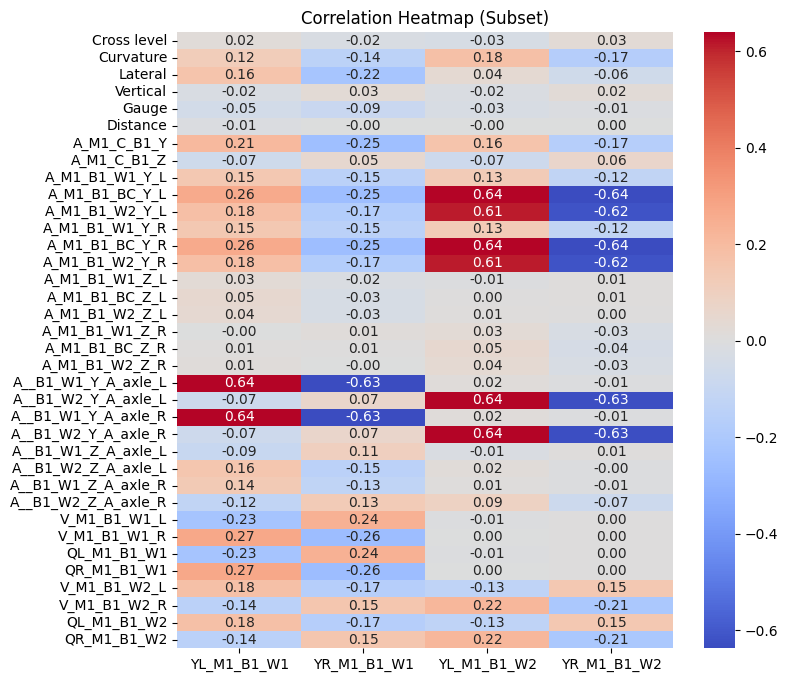

In [46]:
# 독립 변수(a부터 h)와 타겟 변수(i, j) 선택
independent_cols = ['Cross level', 'Curvature', 'Lateral', 'Vertical', 'Gauge', 'Distance',
       'A_M1_C_B1_Y', 'A_M1_C_B1_Z', 'A_M1_B1_W1_Y_L', 'A_M1_B1_BC_Y_L',
       'A_M1_B1_W2_Y_L', 'A_M1_B1_W1_Y_R', 'A_M1_B1_BC_Y_R', 'A_M1_B1_W2_Y_R',
       'A_M1_B1_W1_Z_L', 'A_M1_B1_BC_Z_L', 'A_M1_B1_W2_Z_L', 'A_M1_B1_W1_Z_R',
       'A_M1_B1_BC_Z_R', 'A_M1_B1_W2_Z_R', 'A__B1_W1_Y_A_axle_L',
       'A__B1_W2_Y_A_axle_L', 'A__B1_W1_Y_A_axle_R', 'A__B1_W2_Y_A_axle_R',
       'A__B1_W1_Z_A_axle_L', 'A__B1_W2_Z_A_axle_L', 'A__B1_W1_Z_A_axle_R',
       'A__B1_W2_Z_A_axle_R', 'V_M1_B1_W1_L', 'V_M1_B1_W1_R', 'QL_M1_B1_W1',
       'QR_M1_B1_W1', 'V_M1_B1_W2_L', 'V_M1_B1_W2_R', 'QL_M1_B1_W2',
       'QR_M1_B1_W2']
target_cols = ['YL_M1_B1_W1', 'YR_M1_B1_W1', 'YL_M1_B1_W2', 'YR_M1_B1_W2']

# 선택한 열로 데이터프레임 생성
selected_data = s50_trail[independent_cols + target_cols]

# 상관관계 행렬 계산
correlation_matrix = selected_data.corr()

# 상관관계 행렬 출력
#print(correlation_matrix.loc[independent_cols, target_cols])

# 상관관계 시각화
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix.loc[independent_cols, target_cols], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Subset)")
plt.show()

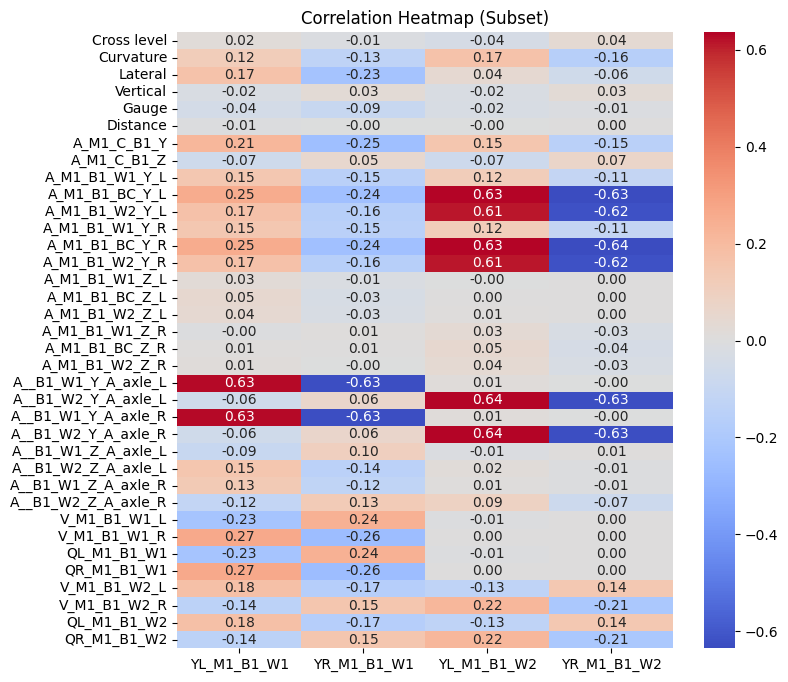

In [45]:
# 독립 변수(a부터 h)와 타겟 변수(i, j) 선택
independent_cols = ['Cross level', 'Curvature', 'Lateral', 'Vertical', 'Gauge', 'Distance',
       'A_M1_C_B1_Y', 'A_M1_C_B1_Z', 'A_M1_B1_W1_Y_L', 'A_M1_B1_BC_Y_L',
       'A_M1_B1_W2_Y_L', 'A_M1_B1_W1_Y_R', 'A_M1_B1_BC_Y_R', 'A_M1_B1_W2_Y_R',
       'A_M1_B1_W1_Z_L', 'A_M1_B1_BC_Z_L', 'A_M1_B1_W2_Z_L', 'A_M1_B1_W1_Z_R',
       'A_M1_B1_BC_Z_R', 'A_M1_B1_W2_Z_R', 'A__B1_W1_Y_A_axle_L',
       'A__B1_W2_Y_A_axle_L', 'A__B1_W1_Y_A_axle_R', 'A__B1_W2_Y_A_axle_R',
       'A__B1_W1_Z_A_axle_L', 'A__B1_W2_Z_A_axle_L', 'A__B1_W1_Z_A_axle_R',
       'A__B1_W2_Z_A_axle_R', 'V_M1_B1_W1_L', 'V_M1_B1_W1_R', 'QL_M1_B1_W1',
       'QR_M1_B1_W1', 'V_M1_B1_W2_L', 'V_M1_B1_W2_R', 'QL_M1_B1_W2',
       'QR_M1_B1_W2']
target_cols = ['YL_M1_B1_W1', 'YR_M1_B1_W1', 'YL_M1_B1_W2', 'YR_M1_B1_W2']

# 선택한 열로 데이터프레임 생성
selected_data = s70_trail[independent_cols + target_cols]

# 상관관계 행렬 계산
correlation_matrix = selected_data.corr()

# 상관관계 행렬 출력
#print(correlation_matrix.loc[independent_cols, target_cols])

# 상관관계 시각화
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix.loc[independent_cols, target_cols], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Subset)")
plt.show()

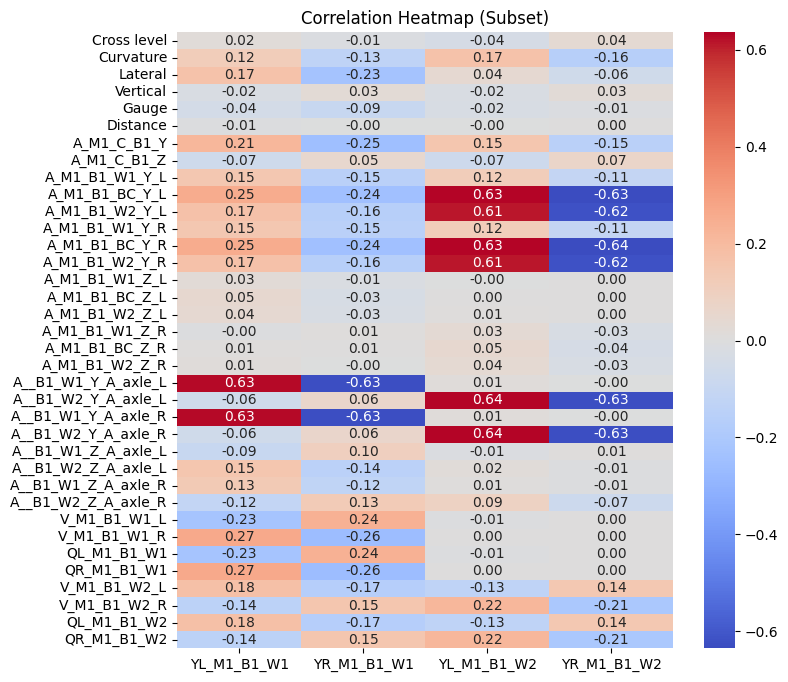

In [44]:
# 독립 변수(a부터 h)와 타겟 변수(i, j) 선택
independent_cols = ['Cross level', 'Curvature', 'Lateral', 'Vertical', 'Gauge', 'Distance',
       'A_M1_C_B1_Y', 'A_M1_C_B1_Z', 'A_M1_B1_W1_Y_L', 'A_M1_B1_BC_Y_L',
       'A_M1_B1_W2_Y_L', 'A_M1_B1_W1_Y_R', 'A_M1_B1_BC_Y_R', 'A_M1_B1_W2_Y_R',
       'A_M1_B1_W1_Z_L', 'A_M1_B1_BC_Z_L', 'A_M1_B1_W2_Z_L', 'A_M1_B1_W1_Z_R',
       'A_M1_B1_BC_Z_R', 'A_M1_B1_W2_Z_R', 'A__B1_W1_Y_A_axle_L',
       'A__B1_W2_Y_A_axle_L', 'A__B1_W1_Y_A_axle_R', 'A__B1_W2_Y_A_axle_R',
       'A__B1_W1_Z_A_axle_L', 'A__B1_W2_Z_A_axle_L', 'A__B1_W1_Z_A_axle_R',
       'A__B1_W2_Z_A_axle_R', 'V_M1_B1_W1_L', 'V_M1_B1_W1_R', 'QL_M1_B1_W1',
       'QR_M1_B1_W1', 'V_M1_B1_W2_L', 'V_M1_B1_W2_R', 'QL_M1_B1_W2',
       'QR_M1_B1_W2']
target_cols = ['YL_M1_B1_W1', 'YR_M1_B1_W1', 'YL_M1_B1_W2', 'YR_M1_B1_W2']

# 선택한 열로 데이터프레임 생성
selected_data = s100_trail[independent_cols + target_cols]

# 상관관계 행렬 계산
correlation_matrix = selected_data.corr()

# 상관관계 행렬 출력
#print(correlation_matrix.loc[independent_cols, target_cols])

# 상관관계 시각화
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix.loc[independent_cols, target_cols], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Subset)")
plt.show()

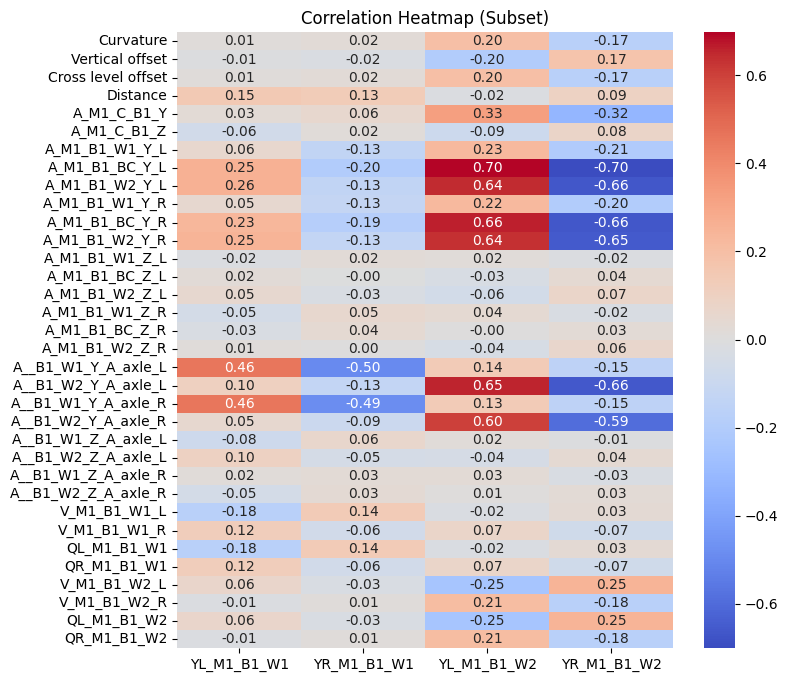

In [43]:
# 독립 변수(a부터 h)와 타겟 변수(i, j) 선택
independent_cols = ['Curvature', 'Vertical offset', 'Cross level offset', 'Distance',
       'A_M1_C_B1_Y', 'A_M1_C_B1_Z', 'A_M1_B1_W1_Y_L', 'A_M1_B1_BC_Y_L',
       'A_M1_B1_W2_Y_L', 'A_M1_B1_W1_Y_R', 'A_M1_B1_BC_Y_R', 'A_M1_B1_W2_Y_R',
       'A_M1_B1_W1_Z_L', 'A_M1_B1_BC_Z_L', 'A_M1_B1_W2_Z_L', 'A_M1_B1_W1_Z_R',
       'A_M1_B1_BC_Z_R', 'A_M1_B1_W2_Z_R', 'A__B1_W1_Y_A_axle_L',
       'A__B1_W2_Y_A_axle_L', 'A__B1_W1_Y_A_axle_R', 'A__B1_W2_Y_A_axle_R',
       'A__B1_W1_Z_A_axle_L', 'A__B1_W2_Z_A_axle_L', 'A__B1_W1_Z_A_axle_R',
       'A__B1_W2_Z_A_axle_R', 'V_M1_B1_W1_L', 'V_M1_B1_W1_R', 'QL_M1_B1_W1',
       'QR_M1_B1_W1', 'V_M1_B1_W2_L', 'V_M1_B1_W2_R', 'QL_M1_B1_W2',
       'QR_M1_B1_W2']
target_cols = ['YL_M1_B1_W1', 'YR_M1_B1_W1', 'YL_M1_B1_W2', 'YR_M1_B1_W2']

# 선택한 열로 데이터프레임 생성
selected_data = c30_trail[independent_cols + target_cols]

# 상관관계 행렬 계산
correlation_matrix = selected_data.corr()

# 상관관계 행렬 출력
#print(correlation_matrix.loc[independent_cols, target_cols])

# 상관관계 시각화
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix.loc[independent_cols, target_cols], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Subset)")
plt.show()

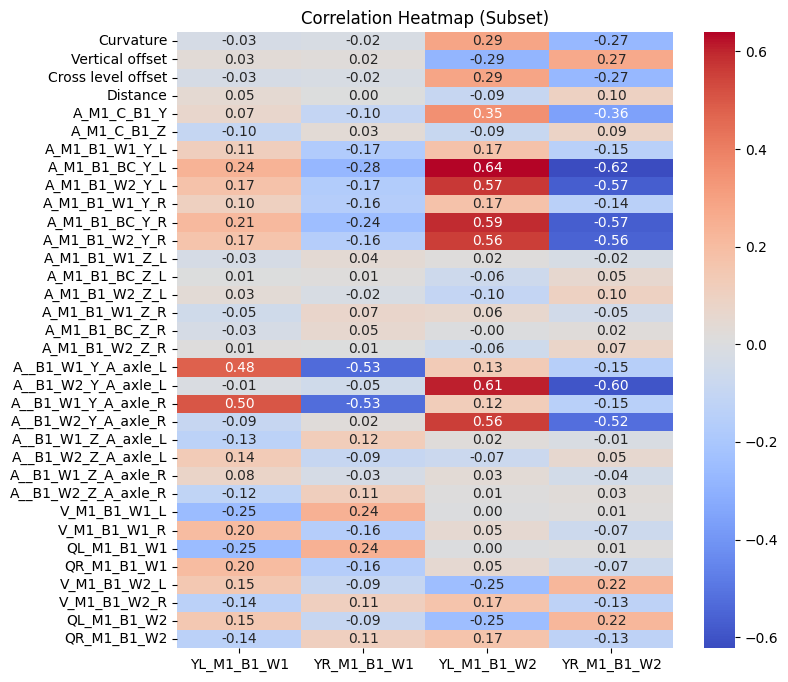

In [42]:
# 독립 변수(a부터 h)와 타겟 변수(i, j) 선택
independent_cols = ['Curvature', 'Vertical offset', 'Cross level offset', 'Distance',
       'A_M1_C_B1_Y', 'A_M1_C_B1_Z', 'A_M1_B1_W1_Y_L', 'A_M1_B1_BC_Y_L',
       'A_M1_B1_W2_Y_L', 'A_M1_B1_W1_Y_R', 'A_M1_B1_BC_Y_R', 'A_M1_B1_W2_Y_R',
       'A_M1_B1_W1_Z_L', 'A_M1_B1_BC_Z_L', 'A_M1_B1_W2_Z_L', 'A_M1_B1_W1_Z_R',
       'A_M1_B1_BC_Z_R', 'A_M1_B1_W2_Z_R', 'A__B1_W1_Y_A_axle_L',
       'A__B1_W2_Y_A_axle_L', 'A__B1_W1_Y_A_axle_R', 'A__B1_W2_Y_A_axle_R',
       'A__B1_W1_Z_A_axle_L', 'A__B1_W2_Z_A_axle_L', 'A__B1_W1_Z_A_axle_R',
       'A__B1_W2_Z_A_axle_R', 'V_M1_B1_W1_L', 'V_M1_B1_W1_R', 'QL_M1_B1_W1',
       'QR_M1_B1_W1', 'V_M1_B1_W2_L', 'V_M1_B1_W2_R', 'QL_M1_B1_W2',
       'QR_M1_B1_W2']
target_cols = ['YL_M1_B1_W1', 'YR_M1_B1_W1', 'YL_M1_B1_W2', 'YR_M1_B1_W2']

# 선택한 열로 데이터프레임 생성
selected_data = c40_trail[independent_cols + target_cols]

# 상관관계 행렬 계산
correlation_matrix = selected_data.corr()

# 상관관계 행렬 출력
#print(correlation_matrix.loc[independent_cols, target_cols])

# 상관관계 시각화
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix.loc[independent_cols, target_cols], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Subset)")
plt.show()

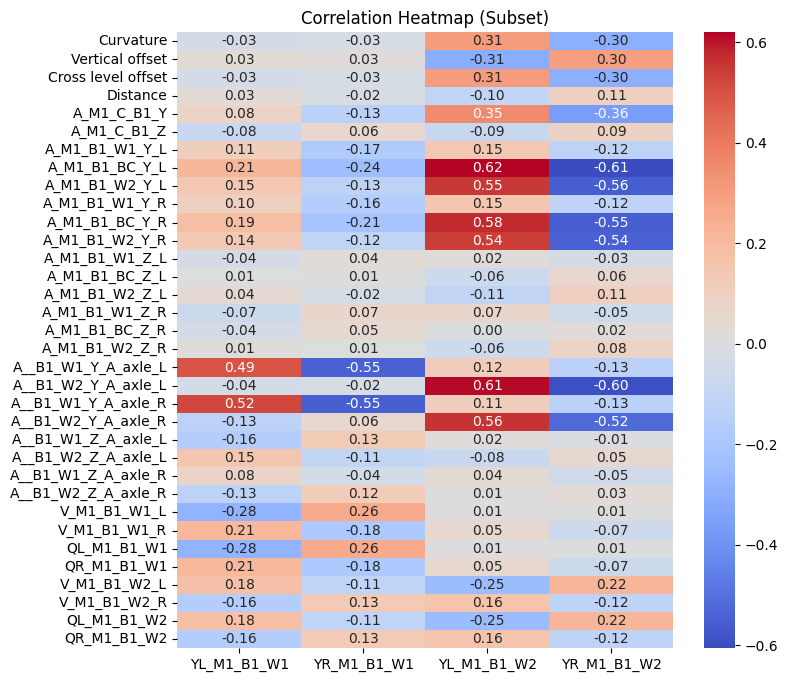

In [39]:
# 독립 변수(a부터 h)와 타겟 변수(i, j) 선택
independent_cols = ['Curvature', 'Vertical offset', 'Cross level offset', 'Distance',
       'A_M1_C_B1_Y', 'A_M1_C_B1_Z', 'A_M1_B1_W1_Y_L', 'A_M1_B1_BC_Y_L',
       'A_M1_B1_W2_Y_L', 'A_M1_B1_W1_Y_R', 'A_M1_B1_BC_Y_R', 'A_M1_B1_W2_Y_R',
       'A_M1_B1_W1_Z_L', 'A_M1_B1_BC_Z_L', 'A_M1_B1_W2_Z_L', 'A_M1_B1_W1_Z_R',
       'A_M1_B1_BC_Z_R', 'A_M1_B1_W2_Z_R', 'A__B1_W1_Y_A_axle_L',
       'A__B1_W2_Y_A_axle_L', 'A__B1_W1_Y_A_axle_R', 'A__B1_W2_Y_A_axle_R',
       'A__B1_W1_Z_A_axle_L', 'A__B1_W2_Z_A_axle_L', 'A__B1_W1_Z_A_axle_R',
       'A__B1_W2_Z_A_axle_R', 'V_M1_B1_W1_L', 'V_M1_B1_W1_R', 'QL_M1_B1_W1',
       'QR_M1_B1_W1', 'V_M1_B1_W2_L', 'V_M1_B1_W2_R', 'QL_M1_B1_W2',
       'QR_M1_B1_W2']
target_cols = ['YL_M1_B1_W1', 'YR_M1_B1_W1', 'YL_M1_B1_W2', 'YR_M1_B1_W2']

# 선택한 열로 데이터프레임 생성
selected_data = c50_trail[independent_cols + target_cols]

# 상관관계 행렬 계산
correlation_matrix = selected_data.corr()

# 상관관계 행렬 출력
#print(correlation_matrix.loc[independent_cols, target_cols])

# 상관관계 시각화
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix.loc[independent_cols, target_cols], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Subset)")
plt.show()

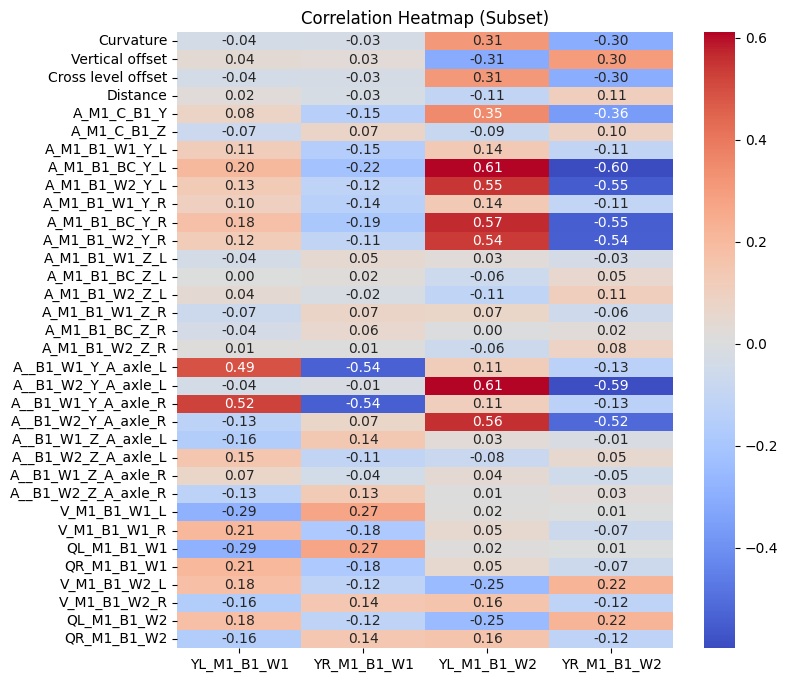

In [40]:
# 독립 변수(a부터 h)와 타겟 변수(i, j) 선택
independent_cols = ['Curvature', 'Vertical offset', 'Cross level offset', 'Distance',
       'A_M1_C_B1_Y', 'A_M1_C_B1_Z', 'A_M1_B1_W1_Y_L', 'A_M1_B1_BC_Y_L',
       'A_M1_B1_W2_Y_L', 'A_M1_B1_W1_Y_R', 'A_M1_B1_BC_Y_R', 'A_M1_B1_W2_Y_R',
       'A_M1_B1_W1_Z_L', 'A_M1_B1_BC_Z_L', 'A_M1_B1_W2_Z_L', 'A_M1_B1_W1_Z_R',
       'A_M1_B1_BC_Z_R', 'A_M1_B1_W2_Z_R', 'A__B1_W1_Y_A_axle_L',
       'A__B1_W2_Y_A_axle_L', 'A__B1_W1_Y_A_axle_R', 'A__B1_W2_Y_A_axle_R',
       'A__B1_W1_Z_A_axle_L', 'A__B1_W2_Z_A_axle_L', 'A__B1_W1_Z_A_axle_R',
       'A__B1_W2_Z_A_axle_R', 'V_M1_B1_W1_L', 'V_M1_B1_W1_R', 'QL_M1_B1_W1',
       'QR_M1_B1_W1', 'V_M1_B1_W2_L', 'V_M1_B1_W2_R', 'QL_M1_B1_W2',
       'QR_M1_B1_W2']
target_cols = ['YL_M1_B1_W1', 'YR_M1_B1_W1', 'YL_M1_B1_W2', 'YR_M1_B1_W2']

# 선택한 열로 데이터프레임 생성
selected_data = c70_trail[independent_cols + target_cols]

# 상관관계 행렬 계산
correlation_matrix = selected_data.corr()

# 상관관계 행렬 출력
#print(correlation_matrix.loc[independent_cols, target_cols])

# 상관관계 시각화
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix.loc[independent_cols, target_cols], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Subset)")
plt.show()

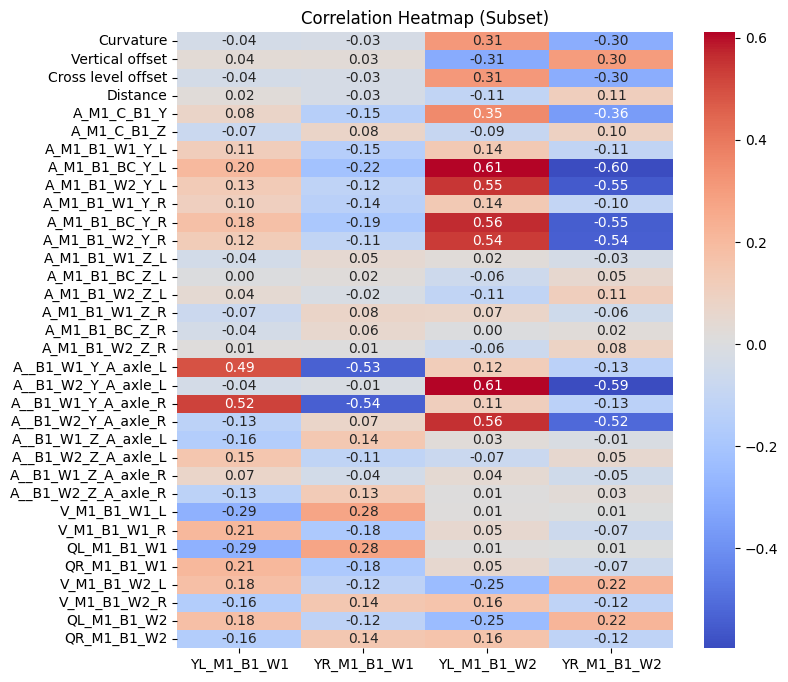

In [41]:
# 독립 변수(a부터 h)와 타겟 변수(i, j) 선택
independent_cols = ['Curvature', 'Vertical offset', 'Cross level offset', 'Distance',
       'A_M1_C_B1_Y', 'A_M1_C_B1_Z', 'A_M1_B1_W1_Y_L', 'A_M1_B1_BC_Y_L',
       'A_M1_B1_W2_Y_L', 'A_M1_B1_W1_Y_R', 'A_M1_B1_BC_Y_R', 'A_M1_B1_W2_Y_R',
       'A_M1_B1_W1_Z_L', 'A_M1_B1_BC_Z_L', 'A_M1_B1_W2_Z_L', 'A_M1_B1_W1_Z_R',
       'A_M1_B1_BC_Z_R', 'A_M1_B1_W2_Z_R', 'A__B1_W1_Y_A_axle_L',
       'A__B1_W2_Y_A_axle_L', 'A__B1_W1_Y_A_axle_R', 'A__B1_W2_Y_A_axle_R',
       'A__B1_W1_Z_A_axle_L', 'A__B1_W2_Z_A_axle_L', 'A__B1_W1_Z_A_axle_R',
       'A__B1_W2_Z_A_axle_R', 'V_M1_B1_W1_L', 'V_M1_B1_W1_R', 'QL_M1_B1_W1',
       'QR_M1_B1_W1', 'V_M1_B1_W2_L', 'V_M1_B1_W2_R', 'QL_M1_B1_W2',
       'QR_M1_B1_W2']
target_cols = ['YL_M1_B1_W1', 'YR_M1_B1_W1', 'YL_M1_B1_W2', 'YR_M1_B1_W2']

# 선택한 열로 데이터프레임 생성
selected_data = c100_trail[independent_cols + target_cols]

# 상관관계 행렬 계산
correlation_matrix = selected_data.corr()

# 상관관계 행렬 출력
#print(correlation_matrix.loc[independent_cols, target_cols])

# 상관관계 시각화
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix.loc[independent_cols, target_cols], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Subset)")
plt.show()

In [40]:
answer_sample = pd.read_csv('/content/drive/My Drive/철도/answer_sample.csv')
data_columns = pd.read_csv('/content/drive/My Drive/철도/data_columns.csv')
lane_data_c = pd.read_csv('/content/drive/My Drive/철도/lane_data_c.csv')
lane_data_columns = pd.read_csv('/content/drive/My Drive/철도/lane_data_columns.csv')
lane_data_s = pd.read_csv('/content/drive/My Drive/철도/lane_data_s.csv')

UnicodeDecodeError: ignored

In [41]:
data_columns

,name,description
0,Distance,거리[m]
1,A_M1_C_B1_Y,대차상부 차체 횡가속도[m/s^2]
2,A_M1_C_B1_Z,대차상부 차체 수직가속도[m/s^2]
3,A_M1_B1_W1_Y_L,좌측 전위 대차 프레임 횡가속도[m/s^2]
4,A_M1_B1_BC_Y_L,좌측 중앙 대차 프레임 횡가속도[m/s^2]
5,A_M1_B1_W2_Y_L,좌측 후위 대차 프레임 횡가속도[m/s^2]
6,A_M1_B1_W1_Y_R,우측 전위 대차 프레임 횡가속도[m/s^2]
7,A_M1_B1_BC_Y_R,우측 중앙 대차 프레임 횡가속도[m/s^2]
8,A_M1_B1_W2_Y_R,우측 후위 대차 프레임 횡가속도[m/s^2]
9,A_M1_B1_W1_Z_L,좌측 전위 대차 프레임 수직가속도[m/s^2]


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, LeakyReLU, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
c30_trail = c30_trail[['Curvature', 'A_M1_B1_BC_Y_L', 'A_M1_B1_W2_Y_L', 'A_M1_B1_BC_Y_R', 'A_M1_B1_W2_Y_R', 'A__B1_W1_Y_A_axle_L', 'A__B1_W2_Y_A_axle_L', 'A__B1_W1_Y_A_axle_R', 'A__B1_W2_Y_A_axle_R',"YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"]]
c40_trail = c40_trail[['Curvature', 'A_M1_B1_BC_Y_L', 'A_M1_B1_W2_Y_L', 'A_M1_B1_BC_Y_R', 'A_M1_B1_W2_Y_R', 'A__B1_W1_Y_A_axle_L', 'A__B1_W2_Y_A_axle_L', 'A__B1_W1_Y_A_axle_R', 'A__B1_W2_Y_A_axle_R',"YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"]]
c50_trail = c50_trail[['Curvature', 'A_M1_B1_BC_Y_L', 'A_M1_B1_W2_Y_L', 'A_M1_B1_BC_Y_R', 'A_M1_B1_W2_Y_R', 'A__B1_W1_Y_A_axle_L', 'A__B1_W2_Y_A_axle_L', 'A__B1_W1_Y_A_axle_R', 'A__B1_W2_Y_A_axle_R',"YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"]]
c70_trail = c70_trail[['Curvature', 'A_M1_B1_BC_Y_L', 'A_M1_B1_W2_Y_L', 'A_M1_B1_BC_Y_R', 'A_M1_B1_W2_Y_R', 'A__B1_W1_Y_A_axle_L', 'A__B1_W2_Y_A_axle_L', 'A__B1_W1_Y_A_axle_R', 'A__B1_W2_Y_A_axle_R',"YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"]]
c100_trail = c100_trail[['Curvature', 'A_M1_B1_BC_Y_L', 'A_M1_B1_W2_Y_L', 'A_M1_B1_BC_Y_R', 'A_M1_B1_W2_Y_R', 'A__B1_W1_Y_A_axle_L', 'A__B1_W2_Y_A_axle_L', 'A__B1_W1_Y_A_axle_R', 'A__B1_W2_Y_A_axle_R',"YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"]]

In [9]:
s30_trail = s30_trail[:10001]
s40_trail = s40_trail[:10001]
s50_trail = s50_trail[:10001]
s70_trail = s70_trail[:10001]
s100_trail = s100_trail[:10001]

c30_trail = c30_trail[:10001]
c40_trail = c40_trail[:10001]
c50_trail = c50_trail[:10001]
c70_trail = c70_trail[:10001]
c100_trail = c100_trail[:10001]

In [17]:


# 데이터 전처리
def prepare_data(filename):
    data = filename
    X = data.drop(columns=["YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"])
    y = data[["YL_M1_B1_W1", "YR_M1_B1_W1", "YL_M1_B1_W2", "YR_M1_B1_W2"]]

    # # 데이터 스케일링
    # scaler = StandardScaler()
    # X = scaler.fit_transform(X)

    # 데이터 정규화
    scaler = MinMaxScaler()  # MinMaxScaler를 사용하여 데이터를 [0, 1] 범위로 정규화
    X = scaler.fit_transform(X)

    return X, y

def reshape_data(X, y):
    X_list, y_list = [], []
    X_padded = np.vstack([np.zeros((N_TIMESTEPS, X.shape[1])), X])

    for i in range(len(X_padded) - N_TIMESTEPS):
        X_list.append(X_padded[i:i+N_TIMESTEPS])
        y_list.append(y.iloc[i])

    return np.array(X_list), np.array(y_list)

data_s_X, data_s_y = prepare_data(c30_trail)

# 모델 구축
N_TIMESTEPS = 10
N_FEATURES = 9

model = Sequential()

model.add(LSTM(100, input_shape=(N_TIMESTEPS, N_FEATURES), return_sequences=True))
model.add(BatchNormalization())
model.add(LeakyReLU())
model.add(Dropout(0.3))

model.add(LSTM(100))
model.add(BatchNormalization())
model.add(LeakyReLU())
model.add(Dropout(0.3))

model.add(Dense(4))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

X_s, y_s = reshape_data(data_s_X, data_s_y)

# 트레이닝/테스트 데이터 나누기
X_train_s = X_s[:8001]
y_train_s = y_s[:8001]
X_test_s = X_s[8001:10001]
y_test_s = y_s[8001:10001]

# Early stopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)

# 모델 학습
model.fit(X_train_s, y_train_s, epochs=100, batch_size=32, validation_data=(X_test_s, y_test_s), callbacks=[es])

# 예측
predictions_30 = model.predict(X_test_s)

# 예측 결과 출력
print("Predictions for data_s")
print(predictions_30[:5])

Epoch 1/100
251/251 [==============================] - 16s 46ms/step - loss: 0.2993 - mae: 0.4031 - val_loss: 0.0109 - val_mae: 0.0728
Epoch 2/100
251/251 [==============================] - 7s 28ms/step - loss: 0.0756 - mae: 0.2075 - val_loss: 0.0063 - val_mae: 0.0512
Epoch 3/100
251/251 [==============================] - 8s 30ms/step - loss: 0.0259 - mae: 0.1174 - val_loss: 0.0096 - val_mae: 0.0578
Epoch 4/100
251/251 [==============================] - 8s 34ms/step - loss: 0.0117 - mae: 0.0752 - val_loss: 0.0074 - val_mae: 0.0553
Epoch 5/100
251/251 [==============================] - 9s 34ms/step - loss: 0.0057 - mae: 0.0515 - val_loss: 0.0080 - val_mae: 0.0563
Epoch 6/100
251/251 [==============================] - 7s 27ms/step - loss: 0.0031 - mae: 0.0361 - val_loss: 0.0050 - val_mae: 0.0388
Epoch 7/100
251/251 [==============================] - 8s 33ms/step - loss: 0.0016 - mae: 0.0273 - val_loss: 0.0039 - val_mae: 0.0329
Epoch 8/100
251/251 [==============================] - 7s 27m

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 표준화 1

Evaluation metrics for data_s:
MAE: 0.027322689961716946
MSE: 0.003531070263152562
RMSE: 0.05942280928357866
R-squared: 0.42846358516689703


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 표준화 2

Evaluation metrics for data_s:
MAE: 0.033558603305341744
MSE: 0.004263245035062963
RMSE: 0.06529352981010418
R-squared: 0.335839764949311


In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 표준화 3

Evaluation metrics for data_s:
MAE: 0.032493394997847196
MSE: 0.004423174818740443
RMSE: 0.06650695316085711
R-squared: 0.3285340744402433


In [56]:

# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 표준화 4

Evaluation metrics for data_s:
MAE: 0.029350107064003154
MSE: 0.0036977110684082077
RMSE: 0.060808807490430265
R-squared: 0.4127724528431318


In [58]:

# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 표준화 5

Evaluation metrics for data_s:
MAE: 0.02907050147901835
MSE: 0.0036922348695805447
RMSE: 0.06076376279971925
R-squared: 0.4199703784770849


In [60]:

# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 표준화 6

Evaluation metrics for data_s:
MAE: 0.027816749902726354
MSE: 0.003778200614069345
RMSE: 0.061467069346678185
R-squared: 0.4218243248841814


In [62]:

# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 표준화 7

Evaluation metrics for data_s:
MAE: 0.028166681067738925
MSE: 0.0034870160613728407
RMSE: 0.059050961561797115
R-squared: 0.44597865742772813


In [64]:

# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 표준화 8

Evaluation metrics for data_s:
MAE: 0.029075441390137534
MSE: 0.003955822994200412
RMSE: 0.06289533364408215
R-squared: 0.3967222857450994


In [66]:

# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 표준화 9

Evaluation metrics for data_s:
MAE: 0.03244901655996546
MSE: 0.004282451288316985
RMSE: 0.0654404407711087
R-squared: 0.3508187586246083


In [68]:

# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 표준화 10

Evaluation metrics for data_s:
MAE: 0.03107795122918578
MSE: 0.0038740795978707636
RMSE: 0.06224210470309277
R-squared: 0.38525685711938584


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 정규화 1

Evaluation metrics for data_s:
MAE: 0.028790194889392134
MSE: 0.003523009523060951
RMSE: 0.059354945228354404
R-squared: 0.4474562062047933


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 정규화 2

Evaluation metrics for data_s:
MAE: 0.029614939712286178
MSE: 0.0036049704451423677
RMSE: 0.060041406088984686
R-squared: 0.4330443655858093


In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 정규화 3

Evaluation metrics for data_s:
MAE: 0.03550246006015194
MSE: 0.003926095686024806
RMSE: 0.06265856434698137
R-squared: 0.3814021281512058


In [70]:

# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 정규화 4

Evaluation metrics for data_s:
MAE: 0.04134614741909202
MSE: 0.0049434548840608175
RMSE: 0.0703097068978446
R-squared: 0.2963048257257767


In [72]:

# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 정규화 5

Evaluation metrics for data_s:
MAE: 0.02762041982805009
MSE: 0.003343033313652411
RMSE: 0.057818970188446034
R-squared: 0.46753079068613135


In [16]:
# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 정규화 6

Evaluation metrics for data_s:
MAE: 0.02875350914285528
MSE: 0.003498643257905765
RMSE: 0.059149330156019225
R-squared: 0.4402198044281453


In [18]:
# 예측과 실제값 간의 MAE, MSE, RMSE, R-squared 계산
mae = mean_absolute_error(y_test_s, predictions_30)
mse = mean_squared_error(y_test_s, predictions_30)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, predictions_30)

# 결과 출력
print("Evaluation metrics for data_s:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)


# 정규화 7

Evaluation metrics for data_s:
MAE: 0.047669909666697985
MSE: 0.005563683886902092
RMSE: 0.07459010582444627
R-squared: 0.25782451314061294


In [14]:
y_test_s

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])